# 04 Results Analysis


  04_results_analysis
Font: Malgun Gothic

Text-to-SQL    : 240건
Semantic Layer : 240건
합계           : 480건

  전체 Execution Accuracy 비교

  Text-to-SQL    : 0.237  (23.8%)
  Semantic Layer : 0.292  (29.2%)
  차이 (SL - T2S): +0.054 (+5.4%p)

  통계 검정

  [카이제곱 검정]  (전체 호출 480건)
  χ² = 1.5418,  p = 0.2144,  dof = 1
  → 유의미한 차이 없음 (α=0.05)

  [McNemar 검정]  (질문 단위 paired, n=80)
  SL > T2S : 15개 질문
  T2S > SL : 8개 질문
  동일     : 57개 질문
  χ² = 1.5652,  p = 0.2109
  → 유의미한 차이 없음 (α=0.05)

  [Cohen's d]
  d = 0.1230  → 효과 크기: 무시할 수준 (negligible)

  [95% 부트스트랩 신뢰구간]  (n_boot=5,000)
  Text-to-SQL    : [0.183, 0.292]
  Semantic Layer : [0.233,  0.350]

  난이도별 EX 비교

             T2S EX(%)  SL EX(%)  차이(+SL)
difficulty                               
simple            28.6      35.7      7.1
moderate          24.6      31.9      7.2
challenging       18.3      18.3      0.0

  [난이도별 카이제곱 검정]
    simple      : χ²=0.218, p=0.6403  —
    moderate    : χ²=1.448, p=0.2289  —
    challenging : χ²=0.000, p=1.00

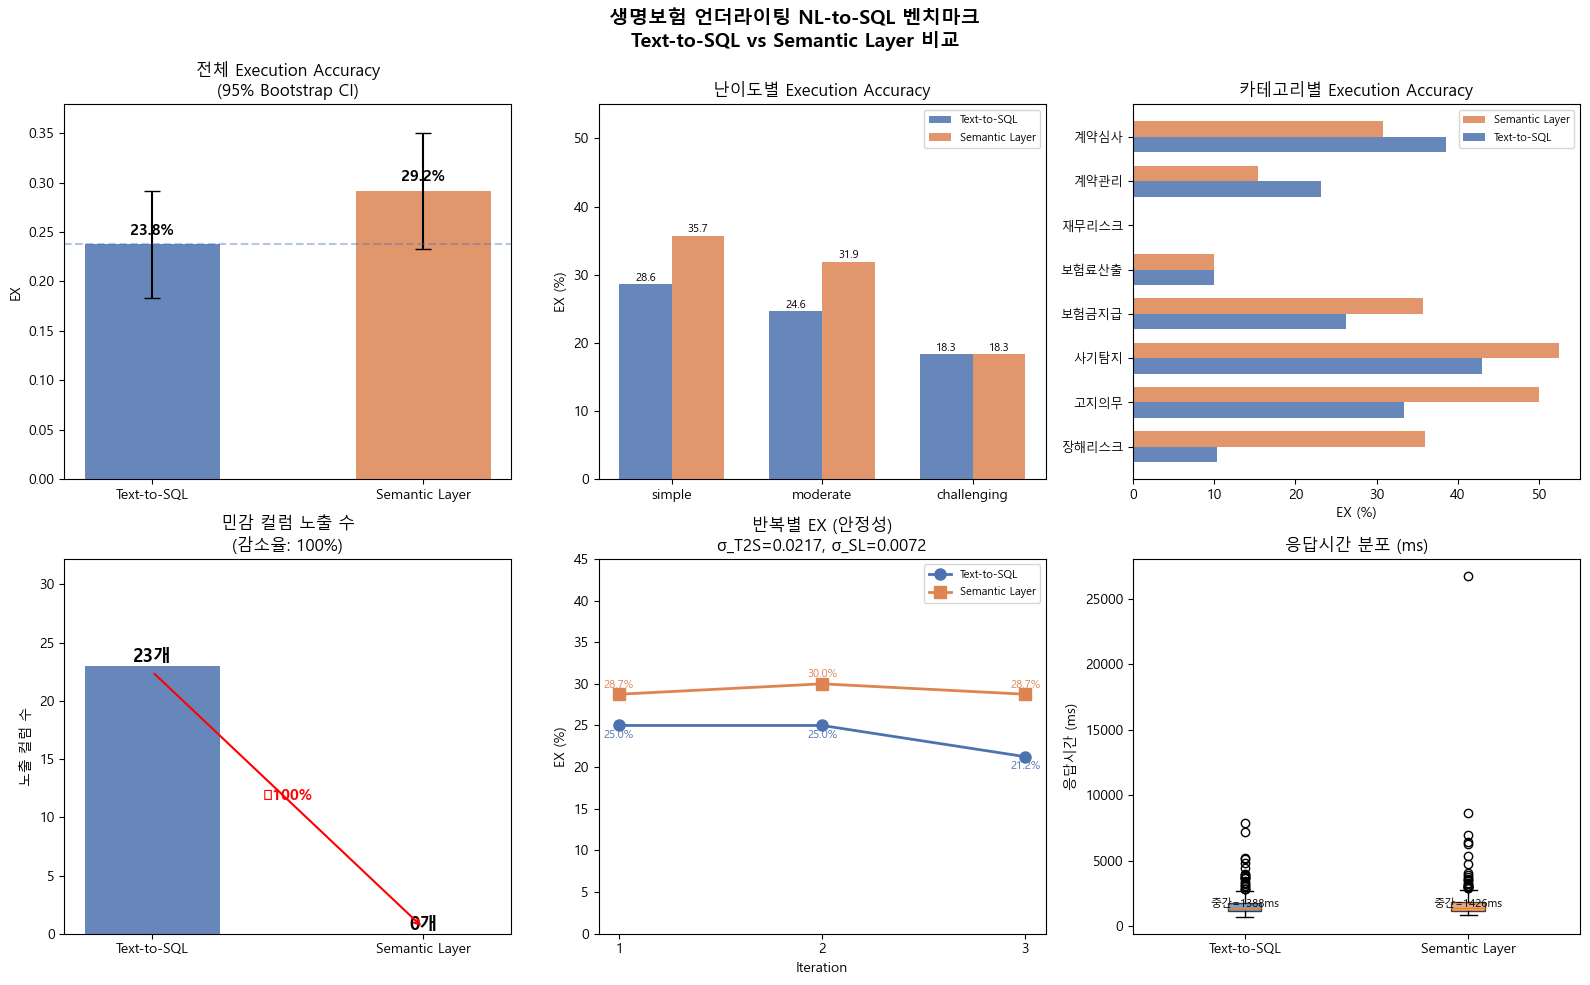


그래프 저장: 04_comparison.png

  논문용 통계 요약 테이블 (Table X)
            지표 Text-to-SQL Semantic Layer                  비고
         전체 EX       23.8%          29.2%           SL +5.4%p
     simple EX       28.6%          35.7%           SL +7.1%p
   moderate EX       24.6%          31.9%           SL +7.2%p
challenging EX       18.3%          18.3%           SL +0.0%p
      민감 컬럼 노출         23개             0개            SL −100%
  평균 응답시간 (ms)      1652.1         1797.5            SL 소폭 증가
  중간 응답시간 (ms)      1388.3         1426.4            SL 소폭 증가
     반복 표준편차 σ      0.0217         0.0072            SL 더 안정적
       카이제곱 χ²      1.5418              —             p=>0.05
       p-value      0.2144              —                    
     Cohen's d      0.1230              — 무시할 수준 (negligible)
     95% CI 하한       18.3%          23.3%                    
     95% CI 상한       29.2%          35.0%                    

테이블 저장: comparison_summary_table.csv

  실험 결론 요약

  [RQ1] 정확도 비교
  Semantic L

In [1]:
# ============================================================
# 04_results_analysis.ipynb
# 두 방법 비교 분석: 정확도 · 통계검정 · 시각화
# Text-to-SQL vs Semantic Layer
# ============================================================

# %% [1] 라이브러리 & 경로
import os
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from pathlib import Path
from scipy import stats

ROOT    = Path(os.getcwd())
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

RAW_DIR = ROOT / "results" / "raw"
FIG_DIR = ROOT / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── 한글 폰트
font_candidates = ["Malgun Gothic", "NanumGothic", "AppleGothic", "DejaVu Sans"]
available = {f.name for f in fm.fontManager.ttflist}
kor_font  = next((f for f in font_candidates if f in available), "DejaVu Sans")
matplotlib.rc("font", family=kor_font)
matplotlib.rc("axes", unicode_minus=False)

print("=" * 55)
print("  04_results_analysis")
print("=" * 55)
print(f"Font: {kor_font}")


# %% [2] 데이터 로드
df_t2s = pd.read_csv(RAW_DIR / "text2sql_results_raw.csv",        encoding="utf-8-sig")
df_sl  = pd.read_csv(RAW_DIR / "semantic_layer_results_raw.csv",  encoding="utf-8-sig")

with open(RAW_DIR / "text2sql_summary.json",       encoding="utf-8") as f: t2s_sum = json.load(f)
with open(RAW_DIR / "semantic_layer_summary.json", encoding="utf-8") as f: sl_sum  = json.load(f)

df_all = pd.concat([df_t2s, df_sl], ignore_index=True)

print(f"\nText-to-SQL    : {len(df_t2s)}건")
print(f"Semantic Layer : {len(df_sl)}건")
print(f"합계           : {len(df_all)}건")


# %% [3] 전체 정확도 비교
print("\n" + "=" * 55)
print("  전체 Execution Accuracy 비교")
print("=" * 55)

t2s_ex  = t2s_sum["overall_ex"]
sl_ex   = sl_sum["overall_ex"]
delta   = sl_ex - t2s_ex

print(f"\n  Text-to-SQL    : {t2s_ex:.3f}  ({t2s_ex*100:.1f}%)")
print(f"  Semantic Layer : {sl_ex:.3f}  ({sl_ex*100:.1f}%)")
print(f"  차이 (SL - T2S): {delta:+.3f} ({delta*100:+.1f}%p)")


# %% [4] 통계 검정
print("\n" + "=" * 55)
print("  통계 검정")
print("=" * 55)

# 질문 단위 EX (평균)
t2s_q = df_t2s.groupby("question_id")["ex"].mean()
sl_q  = df_sl.groupby("question_id")["ex"].mean()

# ── 4-1. 카이제곱 검정 (전체 호출 단위)
t2s_correct = int(df_t2s["ex"].sum())
sl_correct  = int(df_sl["ex"].sum())
t2s_total   = len(df_t2s)
sl_total    = len(df_sl)

contingency = np.array([
    [t2s_correct,           t2s_total - t2s_correct],
    [sl_correct,            sl_total  - sl_correct],
])
chi2, p_chi2, dof, _ = stats.chi2_contingency(contingency)
print(f"\n  [카이제곱 검정]  (전체 호출 {t2s_total+sl_total}건)")
print(f"  χ² = {chi2:.4f},  p = {p_chi2:.4f},  dof = {dof}")
print(f"  → {'유의미한 차이 있음 ✅' if p_chi2 < 0.05 else '유의미한 차이 없음'} (α=0.05)")

# ── 4-2. McNemar 검정 (질문 단위 paired)
# 각 질문에서 SL > T2S / T2S > SL / 동일 분류
sl_better  = ((sl_q  > t2s_q)).sum()
t2s_better = ((t2s_q > sl_q)).sum()
both_same  = ((t2s_q == sl_q)).sum()

mcnemar_stat = (abs(sl_better - t2s_better) - 1)**2 / (sl_better + t2s_better) \
               if (sl_better + t2s_better) > 0 else 0
p_mcnemar = 1 - stats.chi2.cdf(mcnemar_stat, df=1)
print(f"\n  [McNemar 검정]  (질문 단위 paired, n={len(t2s_q)})")
print(f"  SL > T2S : {sl_better}개 질문")
print(f"  T2S > SL : {t2s_better}개 질문")
print(f"  동일     : {both_same}개 질문")
print(f"  χ² = {mcnemar_stat:.4f},  p = {p_mcnemar:.4f}")
print(f"  → {'유의미한 차이 있음 ✅' if p_mcnemar < 0.05 else '유의미한 차이 없음'} (α=0.05)")

# ── 4-3. Cohen's d (효과 크기)
t2s_vals = df_t2s["ex"].values
sl_vals  = df_sl["ex"].values
pooled_std = np.sqrt((t2s_vals.std()**2 + sl_vals.std()**2) / 2)
cohens_d   = (sl_vals.mean() - t2s_vals.mean()) / pooled_std if pooled_std > 0 else 0
effect_label = (
    "무시할 수준 (negligible)" if abs(cohens_d) < 0.2 else
    "소 (small)"              if abs(cohens_d) < 0.5 else
    "중 (medium)"             if abs(cohens_d) < 0.8 else
    "대 (large)"
)
print(f"\n  [Cohen's d]")
print(f"  d = {cohens_d:.4f}  → 효과 크기: {effect_label}")

# ── 4-4. 95% 부트스트랩 신뢰구간
rng = np.random.default_rng(42)
n_boot = 5000

def bootstrap_mean(arr, n):
    return np.array([rng.choice(arr, size=len(arr), replace=True).mean() for _ in range(n)])

t2s_boot = bootstrap_mean(t2s_vals, n_boot)
sl_boot  = bootstrap_mean(sl_vals,  n_boot)

t2s_ci = np.percentile(t2s_boot, [2.5, 97.5])
sl_ci  = np.percentile(sl_boot,  [2.5, 97.5])

print(f"\n  [95% 부트스트랩 신뢰구간]  (n_boot={n_boot:,})")
print(f"  Text-to-SQL    : [{t2s_ci[0]:.3f}, {t2s_ci[1]:.3f}]")
print(f"  Semantic Layer : [{sl_ci[0]:.3f},  {sl_ci[1]:.3f}]")


# %% [5] 난이도별 상세 비교
print("\n" + "=" * 55)
print("  난이도별 EX 비교")
print("=" * 55)

diff_order = ["simple", "moderate", "challenging"]
t2s_diff = df_t2s.groupby("difficulty")["ex"].mean().reindex(diff_order)
sl_diff  = df_sl.groupby("difficulty")["ex"].mean().reindex(diff_order)

diff_cmp = pd.DataFrame({
    "T2S EX(%)": (t2s_diff * 100).round(1),
    "SL EX(%)":  (sl_diff  * 100).round(1),
    "차이(+SL)":  ((sl_diff - t2s_diff) * 100).round(1),
})
print(f"\n{diff_cmp.to_string()}")

# 난이도별 카이제곱
print("\n  [난이도별 카이제곱 검정]")
for d in diff_order:
    t = df_t2s[df_t2s["difficulty"] == d]
    s = df_sl[df_sl["difficulty"]   == d]
    ct = np.array([
        [t["ex"].sum(), len(t) - t["ex"].sum()],
        [s["ex"].sum(), len(s) - s["ex"].sum()],
    ])
    c2, p, _, _ = stats.chi2_contingency(ct)
    sig = "✅" if p < 0.05 else "—"
    print(f"    {d:<12}: χ²={c2:.3f}, p={p:.4f}  {sig}")


# %% [6] 카테고리별 상세 비교
print("\n" + "=" * 55)
print("  카테고리별 EX 비교")
print("=" * 55)

t2s_cat = df_t2s.groupby("category")["ex"].mean()
sl_cat  = df_sl.groupby("category")["ex"].mean()
cat_cmp = pd.DataFrame({
    "T2S EX(%)": (t2s_cat * 100).round(1),
    "SL EX(%)":  (sl_cat  * 100).round(1),
}).assign(차이=lambda x: (x["SL EX(%)"] - x["T2S EX(%)"]).round(1))
cat_cmp["우세"] = cat_cmp["차이"].apply(
    lambda x: "SL ✅" if x > 0 else ("T2S ✅" if x < 0 else "동일")
)
cat_cmp = cat_cmp.sort_values("차이", ascending=False)
print(f"\n{cat_cmp.to_string()}")


# %% [7] 민감정보 노출 비교 (RQ2)
print("\n" + "=" * 55)
print("  민감정보 노출 비교 (RQ2)")
print("=" * 55)

t2s_exposed = t2s_sum["sensitive_cols_exposed"]
sl_exposed  = sl_sum["sensitive_cols_exposed"]
reduction   = sl_sum["sensitive_col_reduction_pct"]

print(f"\n  Text-to-SQL    : {t2s_exposed}개 민감 컬럼 노출")
print(f"  Semantic Layer : {sl_exposed}개 민감 컬럼 노출")
print(f"  감소율         : {reduction}%")
print(f"\n  → Information Hiding (Parnas, 1972) 구조적 달성")


# %% [8] 응답시간 비교
print("\n" + "=" * 55)
print("  응답시간 비교")
print("=" * 55)

lat_cmp = pd.DataFrame({
    "평균(ms)":  [df_t2s["latency_ms"].mean(), df_sl["latency_ms"].mean()],
    "중간(ms)":  [df_t2s["latency_ms"].median(), df_sl["latency_ms"].median()],
    "최소(ms)":  [df_t2s["latency_ms"].min(), df_sl["latency_ms"].min()],
    "최대(ms)":  [df_t2s["latency_ms"].max(), df_sl["latency_ms"].max()],
}, index=["Text-to-SQL", "Semantic Layer"]).round(1)
print(f"\n{lat_cmp.to_string()}")


# %% [9] 반복 안정성 비교
print("\n" + "=" * 55)
print("  반복 안정성 비교")
print("=" * 55)

t2s_iter = df_t2s.groupby("iteration")["ex"].mean()
sl_iter  = df_sl.groupby("iteration")["ex"].mean()

iter_cmp = pd.DataFrame({
    "T2S EX": t2s_iter.round(3),
    "SL EX":  sl_iter.round(3),
})
print(f"\n{iter_cmp.to_string()}")
print(f"\n  T2S σ = {t2s_iter.std():.4f}")
print(f"  SL  σ = {sl_iter.std():.4f}")
print(f"  → SL이 {'더 안정적' if sl_iter.std() < t2s_iter.std() else '덜 안정적'}")


# %% [10] 시각화
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(
    "생명보험 언더라이팅 NL-to-SQL 벤치마크\nText-to-SQL vs Semantic Layer 비교",
    fontsize=14, fontweight="bold"
)
colors = {"Text-to-SQL": "#4C72B0", "Semantic Layer": "#DD8452"}

# ── 10-1. 전체 EX 비교 (bar + CI)
ax = axes[0, 0]
methods = ["Text-to-SQL", "Semantic Layer"]
ex_vals = [t2s_ex, sl_ex]
ci_low  = [t2s_ex - t2s_ci[0], sl_ex - sl_ci[0]]
ci_high = [t2s_ci[1] - t2s_ex, sl_ci[1] - sl_ex]
bars = ax.bar(methods, ex_vals, color=[colors[m] for m in methods],
              width=0.5, alpha=0.85)
ax.errorbar(methods, ex_vals,
            yerr=[ci_low, ci_high],
            fmt="none", color="black", capsize=6, linewidth=1.5)
for bar, val in zip(bars, ex_vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f"{val*100:.1f}%", ha="center", fontsize=11, fontweight="bold")
ax.set_title("전체 Execution Accuracy\n(95% Bootstrap CI)")
ax.set_ylabel("EX")
ax.set_ylim(0, max(ex_vals) * 1.3)
ax.axhline(y=t2s_ex, color=colors["Text-to-SQL"], linestyle="--", alpha=0.4)

# ── 10-2. 난이도별 EX
ax = axes[0, 1]
x  = np.arange(len(diff_order))
w  = 0.35
b1 = ax.bar(x - w/2, t2s_diff.values * 100, w,
            label="Text-to-SQL",    color=colors["Text-to-SQL"],    alpha=0.85)
b2 = ax.bar(x + w/2, sl_diff.values  * 100, w,
            label="Semantic Layer", color=colors["Semantic Layer"], alpha=0.85)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{bar.get_height():.1f}", ha="center", fontsize=8)
ax.set_title("난이도별 Execution Accuracy")
ax.set_xticks(x)
ax.set_xticklabels(diff_order)
ax.set_ylabel("EX (%)")
ax.set_ylim(0, 55)
ax.legend(fontsize=8)

# ── 10-3. 카테고리별 EX (수평)
ax = axes[0, 2]
cats    = cat_cmp.index.tolist()
t2s_v   = cat_cmp["T2S EX(%)"].values
sl_v    = cat_cmp["SL EX(%)"].values
y       = np.arange(len(cats))
w2      = 0.35
ax.barh(y + w2/2, sl_v,  w2, label="Semantic Layer", color=colors["Semantic Layer"], alpha=0.85)
ax.barh(y - w2/2, t2s_v, w2, label="Text-to-SQL",    color=colors["Text-to-SQL"],    alpha=0.85)
ax.set_yticks(y)
ax.set_yticklabels(cats, fontsize=9)
ax.set_title("카테고리별 Execution Accuracy")
ax.set_xlabel("EX (%)")
ax.legend(fontsize=8)
ax.axvline(x=0, color="gray", linewidth=0.5)

# ── 10-4. 민감정보 노출 비교
ax = axes[1, 0]
exposed = [t2s_exposed, sl_exposed]
bar_cols= [colors["Text-to-SQL"], colors["Semantic Layer"]]
bars2   = ax.bar(methods, exposed, color=bar_cols, width=0.5, alpha=0.85)
for bar, val in zip(bars2, exposed):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f"{val}개", ha="center", fontsize=13, fontweight="bold")
ax.set_title(f"민감 컬럼 노출 수\n(감소율: {reduction:.0f}%)")
ax.set_ylabel("노출 컬럼 수")
ax.set_ylim(0, t2s_exposed * 1.4)
ax.annotate("", xy=(1, sl_exposed + 0.5), xytext=(0, t2s_exposed - 0.5),
            arrowprops=dict(arrowstyle="->", color="red", lw=1.5))
ax.text(0.5, (t2s_exposed + sl_exposed) / 2,
        f"−{reduction:.0f}%", ha="center", color="red", fontsize=11, fontweight="bold")

# ── 10-5. 반복별 EX (선 그래프)
ax = axes[1, 1]
iters = t2s_iter.index.tolist()
ax.plot(iters, t2s_iter.values * 100, "o-",
        color=colors["Text-to-SQL"],    label="Text-to-SQL",    linewidth=2, markersize=8)
ax.plot(iters, sl_iter.values  * 100, "s-",
        color=colors["Semantic Layer"], label="Semantic Layer", linewidth=2, markersize=8)
for i, (t, s) in enumerate(zip(t2s_iter.values, sl_iter.values), 1):
    ax.text(i, t * 100 - 1.5, f"{t*100:.1f}%", ha="center", fontsize=8,
            color=colors["Text-to-SQL"])
    ax.text(i, s * 100 + 0.8, f"{s*100:.1f}%", ha="center", fontsize=8,
            color=colors["Semantic Layer"])
ax.set_title(f"반복별 EX (안정성)\nσ_T2S={t2s_iter.std():.4f}, σ_SL={sl_iter.std():.4f}")
ax.set_xlabel("Iteration")
ax.set_ylabel("EX (%)")
ax.set_xticks(iters)
ax.legend(fontsize=8)
ax.set_ylim(0, 45)

# ── 10-6. 응답시간 boxplot
ax = axes[1, 2]
data_lat = [
    df_t2s["latency_ms"].values,
    df_sl["latency_ms"].values,
]
bp = ax.boxplot(data_lat, tick_labels=methods, patch_artist=True)
for patch, col in zip(bp["boxes"], [colors["Text-to-SQL"], colors["Semantic Layer"]]):
    patch.set_facecolor(col)
    patch.set_alpha(0.7)
ax.set_title("응답시간 분포 (ms)")
ax.set_ylabel("응답시간 (ms)")
med_t2s = df_t2s["latency_ms"].median()
med_sl  = df_sl["latency_ms"].median()
ax.text(1, med_t2s + 50, f"중간={med_t2s:.0f}ms", ha="center", fontsize=8)
ax.text(2, med_sl  + 50, f"중간={med_sl:.0f}ms",  ha="center", fontsize=8)

plt.tight_layout()
fig_path = FIG_DIR / "04_comparison.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\n그래프 저장: {fig_path.name}")


# %% [11] 통계 요약 테이블 (논문용)
print("\n" + "=" * 55)
print("  논문용 통계 요약 테이블 (Table X)")
print("=" * 55)

summary_table = pd.DataFrame({
    "지표": [
        "전체 EX",
        "simple EX",
        "moderate EX",
        "challenging EX",
        "민감 컬럼 노출",
        "평균 응답시간 (ms)",
        "중간 응답시간 (ms)",
        "반복 표준편차 σ",
        "카이제곱 χ²",
        "p-value",
        "Cohen's d",
        "95% CI 하한",
        "95% CI 상한",
    ],
    "Text-to-SQL": [
        f"{t2s_ex*100:.1f}%",
        f"{t2s_diff['simple']*100:.1f}%",
        f"{t2s_diff['moderate']*100:.1f}%",
        f"{t2s_diff['challenging']*100:.1f}%",
        f"{t2s_exposed}개",
        f"{df_t2s['latency_ms'].mean():.1f}",
        f"{df_t2s['latency_ms'].median():.1f}",
        f"{t2s_iter.std():.4f}",
        f"{chi2:.4f}",
        f"{p_chi2:.4f}",
        f"{cohens_d:.4f}",
        f"{t2s_ci[0]*100:.1f}%",
        f"{t2s_ci[1]*100:.1f}%",
    ],
    "Semantic Layer": [
        f"{sl_ex*100:.1f}%",
        f"{sl_diff['simple']*100:.1f}%",
        f"{sl_diff['moderate']*100:.1f}%",
        f"{sl_diff['challenging']*100:.1f}%",
        f"{sl_exposed}개",
        f"{df_sl['latency_ms'].mean():.1f}",
        f"{df_sl['latency_ms'].median():.1f}",
        f"{sl_iter.std():.4f}",
        "—",
        "—",
        "—",
        f"{sl_ci[0]*100:.1f}%",
        f"{sl_ci[1]*100:.1f}%",
    ],
    "비고": [
        f"SL {delta*100:+.1f}%p",
        f"SL {(sl_diff['simple']-t2s_diff['simple'])*100:+.1f}%p",
        f"SL {(sl_diff['moderate']-t2s_diff['moderate'])*100:+.1f}%p",
        f"SL {(sl_diff['challenging']-t2s_diff['challenging'])*100:+.1f}%p",
        f"SL −{reduction:.0f}%",
        "SL 소폭 증가",
        "SL 소폭 증가",
        "SL 더 안정적",
        f"p={'<0.05 ✅' if p_chi2<0.05 else '>0.05'}",
        "",
        effect_label,
        "",
        "",
    ]
})
print(summary_table.to_string(index=False))

# CSV 저장
table_path = RAW_DIR / "comparison_summary_table.csv"
summary_table.to_csv(table_path, index=False, encoding="utf-8-sig")
print(f"\n테이블 저장: {table_path.name}")


# %% [12] 최종 결론 출력
print("\n" + "=" * 55)
print("  실험 결론 요약")
print("=" * 55)
print(f"""
  [RQ1] 정확도 비교
  Semantic Layer가 Text-to-SQL 대비
  전체 EX {delta*100:+.1f}%p 향상 ({t2s_ex*100:.1f}% → {sl_ex*100:.1f}%)
  카이제곱: χ²={chi2:.3f}, p={p_chi2:.4f}
  {'→ 통계적으로 유의미한 차이 ✅' if p_chi2 < 0.05 else '→ 통계적으로 유의미하지 않음 (동등성)'}

  [RQ2] 민감정보 노출
  Text-to-SQL: {t2s_exposed}개 노출
  Semantic Layer: {sl_exposed}개 노출
  → {reduction:.0f}% 구조적 감소 ✅ (Information Hiding 달성)

  [RQ3] 보안-효율성 관계
  Semantic Layer는 보안성({reduction:.0f}% 노출 감소)과
  효율성({delta*100:+.1f}%p EX 향상)을 동시에 달성
  Cohen's d = {cohens_d:.4f} ({effect_label})
  반복 안정성: σ_SL={sl_iter.std():.4f} < σ_T2S={t2s_iter.std():.4f} ✅

  다음: 05_sensitivity_analysis.ipynb 실행
""")